In [1]:
pip install matplotlib


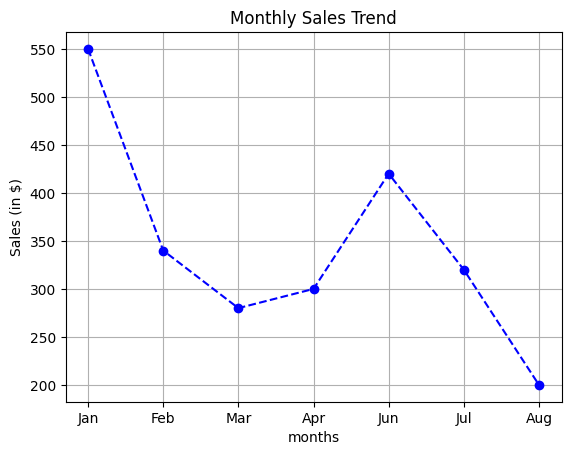

In [5]:
import matplotlib.pyplot as plt
months=['Jan','Feb','Mar','Apr','Jun','Jul','Aug']
sales=[550,340,280,300,420,320,200]
plt.plot(months,sales,color='blue',marker='o',linestyle='--')
plt.title("Monthly Sales Trend")
plt.xlabel("months")
plt.ylabel("Sales (in $)")
plt.grid(True)
plt.show()

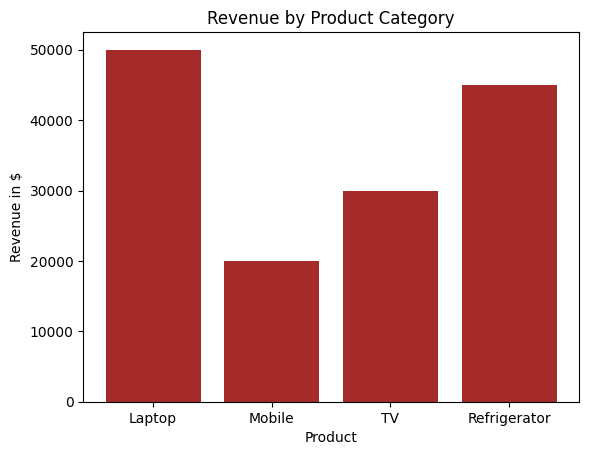

In [6]:
import matplotlib.pyplot as plt
products=['Laptop','Mobile','TV','Refrigerator']
revenue=[50000,20000,30000,45000]
plt.bar(products,revenue,color='brown')
plt.title("Revenue by Product Category")
plt.xlabel("Product")
plt.ylabel("Revenue in $")
plt.show()

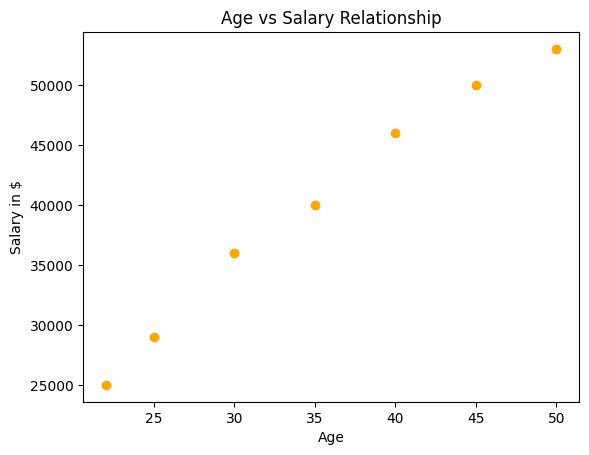

In [9]:
import matplotlib.pyplot as plt
age=[22,25,30,35,40,45,50]
salary=[25000,29000,36000,40000,46000,50000,53000]
plt.scatter(age,salary,color='orange')
plt.title("Age vs Salary Relationship")
plt.xlabel("Age")
plt.ylabel("Salary in $")
plt.show()

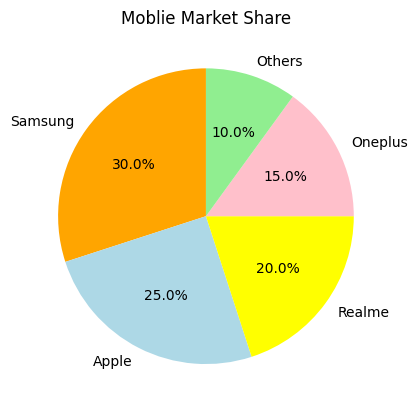

In [11]:
import matplotlib.pyplot as plt
brands=['Samsung','Apple','Realme','Oneplus','Others']
market_share=[30,25,20,15,10]
colors=['orange','lightblue','yellow','pink','lightgreen']
plt.pie(market_share,labels=brands,colors=colors,autopct='%1.1f%%',startangle=90)
plt.title("Moblie Market Share")
plt.show()

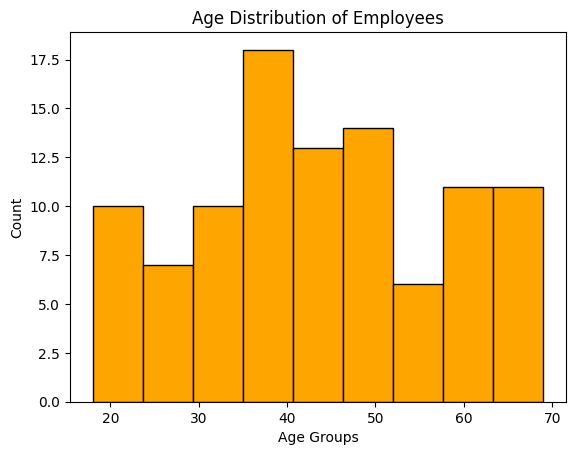

In [13]:
import matplotlib.pyplot as plt
import numpy as np
ages=np.random.randint(18,70,100)
plt.hist(ages,bins=9,color='orange',edgecolor='black')
plt.title("Age Distribution of Employees")
plt.xlabel("Age Groups")
plt.ylabel("Count")
plt.show()

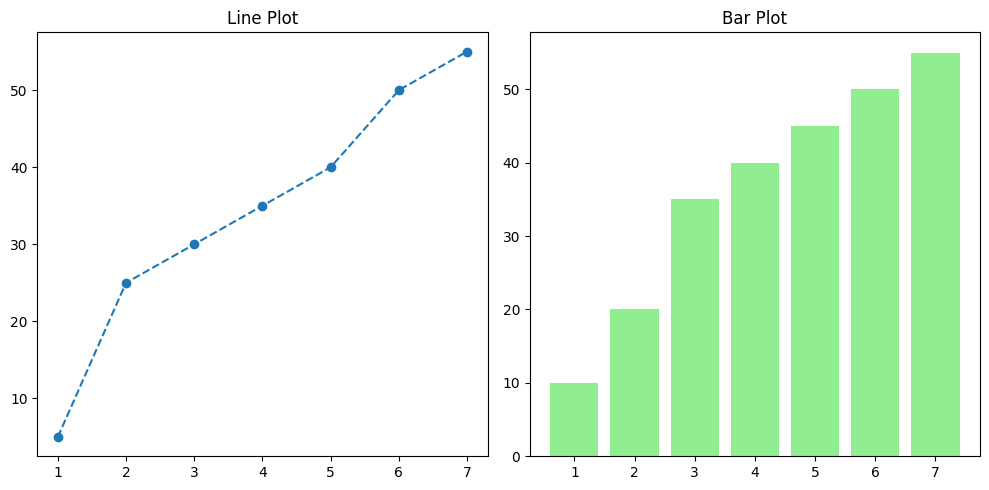

In [19]:
import matplotlib.pyplot as plt
x=[1,2,3,4,5,6,7]
y1=[5,25,30,35,40,50,55]
y2=[10,20,35,40,45,50,55]
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(x,y1,'o--')
plt.title("Line Plot")
plt.subplot(1,2,2)
plt.bar(x,y2,color='lightgreen')
plt.title("Bar Plot")
plt.tight_layout()
plt.show()

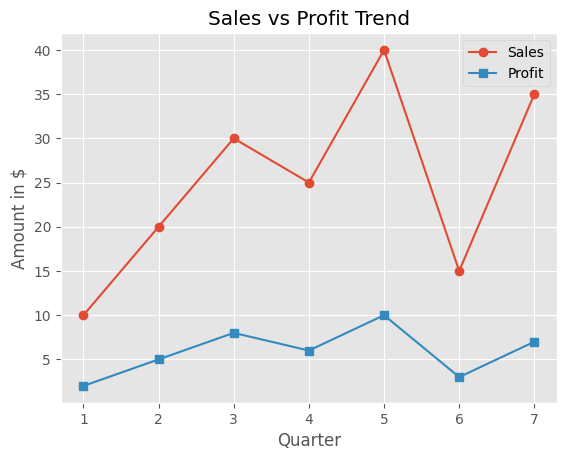

In [22]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')
x=[1,2,3,4,5,6,7]
sales=[10,20,30,25,40,15,35]
profit=[2,5,8,6,10,3,7,]
plt.plot(x,sales,label='Sales',marker='o')
plt.plot(x,profit,label='Profit',marker='s')
plt.title("Sales vs Profit Trend")
plt.xlabel("Quarter")
plt.ylabel("Amount in $")
plt.legend()
plt.savefig("sales_profit_chart.png")
plt.show()

In [24]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [25]:
import pandas as pd

df = pd.read_csv('data.csv')

  Inspect the dataset and list the number of rows, columns, data types, and any missing values.
•  Remove duplicate rows (if any) and re-check the dataset — how many rows were removed?
•  Parse the Date column to datetime, sort the data by date, and report how many rows (if any) have invalid/missing dates.
•  Handle missing values in numeric columns (explain and apply a method you choose), then state which method you used and why.

In [30]:

print("Shape of dataset (rows, columns):", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values per Column:\n", df.isnull().sum())

Shape of dataset (rows, columns): (32, 5)

Data Types:
 Duration      int64
Date         object
Pulse         int64
Maxpulse      int64
Calories    float64
dtype: object

Missing Values per Column:
 Duration    0
Date        1
Pulse       0
Maxpulse    0
Calories    2
dtype: int64


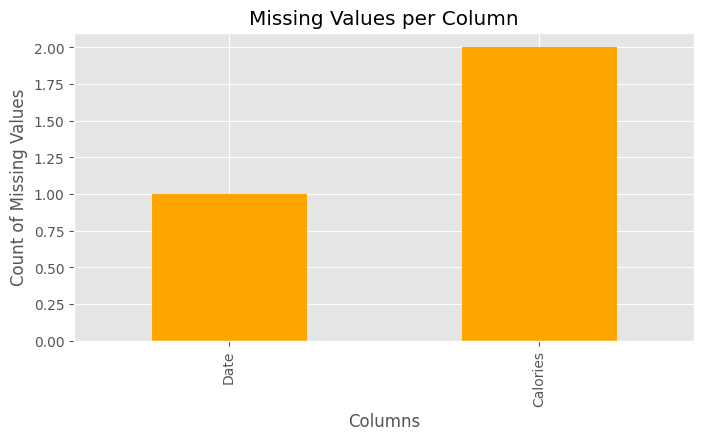

In [26]:
import matplotlib.pyplot as plt

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
plt.figure(figsize=(8, 4))
missing_values.plot(kind='bar', color='orange')
plt.title("Missing Values per Column")
plt.ylabel("Count of Missing Values")
plt.xlabel("Columns")
plt.show()


In [31]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
df = df.drop_duplicates()
print("New shape after removing duplicates:", df.shape)
print(f"Rows removed: {duplicates}")

Number of duplicate rows: 1
New shape after removing duplicates: (31, 5)
Rows removed: 1


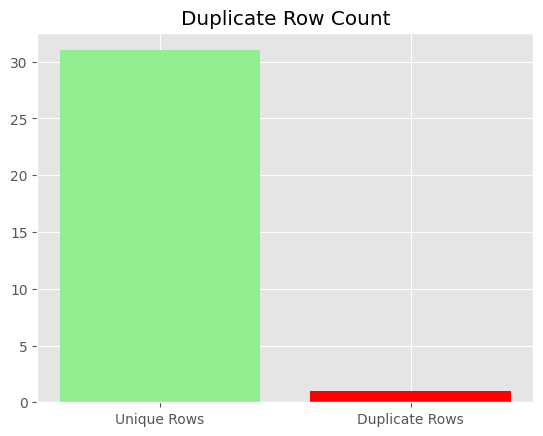

In [27]:
duplicates = df.duplicated().sum()

plt.bar(['Unique Rows', 'Duplicate Rows'], [len(df)-duplicates, duplicates], color=['lightgreen', 'red'])
plt.title("Duplicate Row Count")
plt.show()


In [32]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
invalid_dates = df['Date'].isna().sum()
print(f"Number of invalid or missing dates: {invalid_dates}")
df = df.sort_values(by='Date')

Number of invalid or missing dates: 1


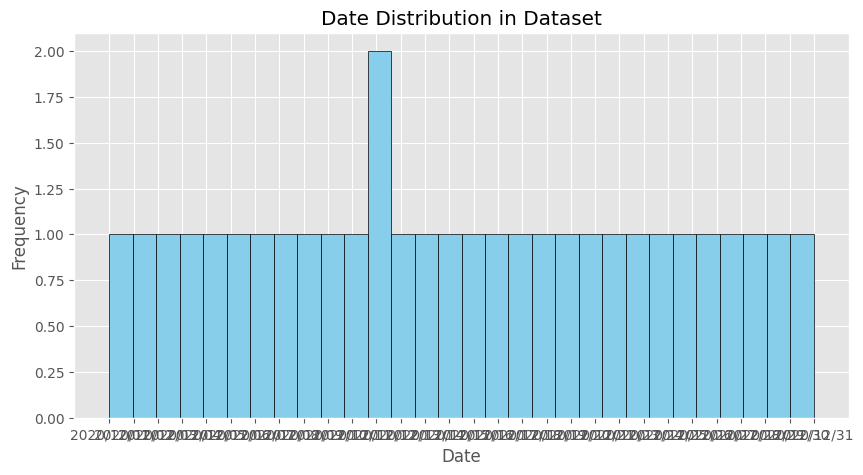

In [28]:
plt.figure(figsize=(10, 5))
plt.hist(df['Date'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title("Date Distribution in Dataset")
plt.xlabel("Date")
plt.ylabel("Frequency")
plt.show()


In [33]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
print("Missing values after filling:\n", df[numeric_cols].isnull().sum())
print("\nMethod used: Median imputation (chosen to reduce effect of outliers)")


Missing values after filling:
 Duration    0
Pulse       0
Maxpulse    0
Calories    0
dtype: int64

Method used: Median imputation (chosen to reduce effect of outliers)


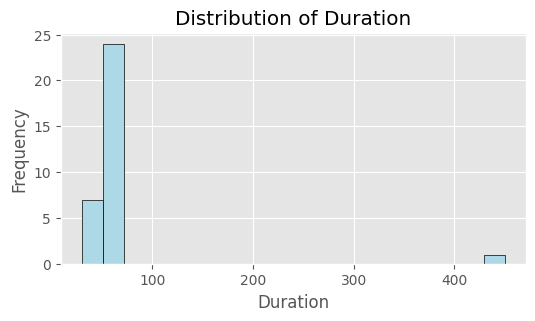

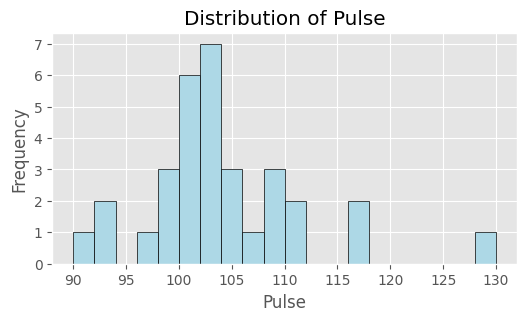

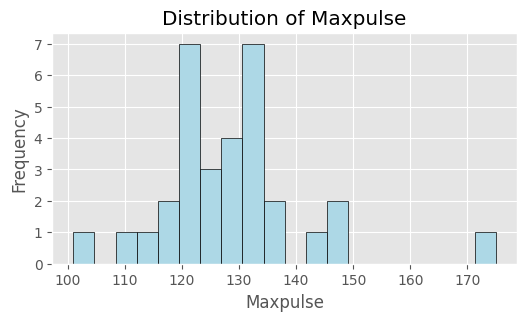

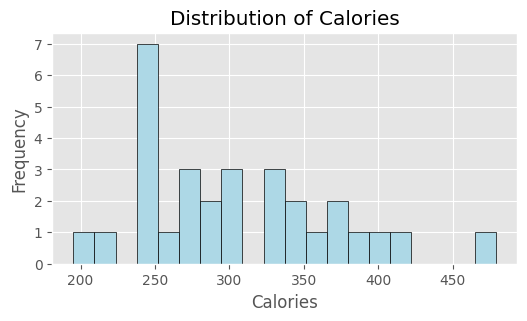

In [29]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    plt.hist(df[col], bins=20, color='lightblue', edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


Create a line plot of Calories over Date (with markers, dashed line, grid, rotated x-ticks) and save the image as line_calories_over_time.png.

Rows removed (missing/invalid Date or Calories): 3


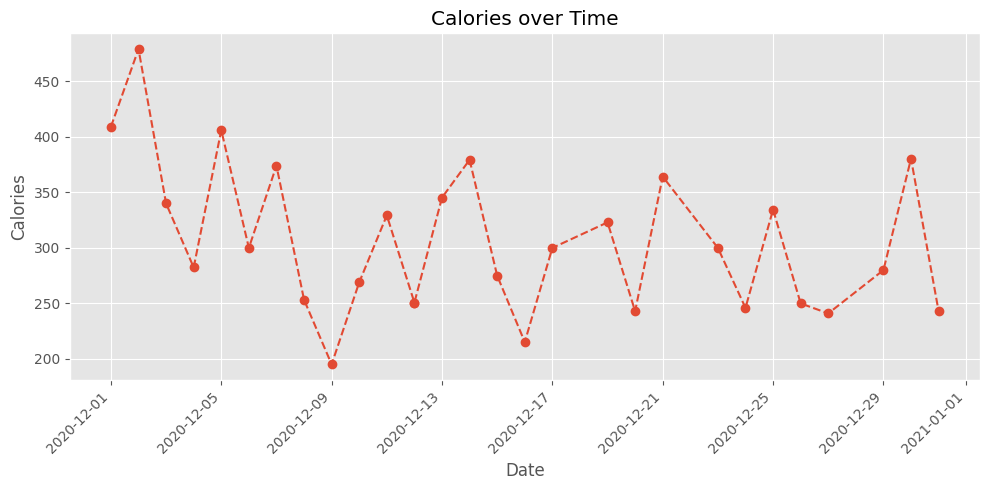

Saved: line_calories_over_time.png


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
# 1) Load
df = pd.read_csv('data.csv')
# 2) Locate columns (case-insensitive)
cols_lower = {c.lower(): c for c in df.columns}
date_col = cols_lower.get('date')
cal_col = cols_lower.get('calories')
if date_col is None or cal_col is None:
    raise ValueError("CSV must contain 'Date' and 'Calories' columns (case-insensitive).")
# 3) Parse and clean
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
before = len(df)
df = df.dropna(subset=[date_col, cal_col])
df[cal_col] = pd.to_numeric(df[cal_col], errors='coerce')
df = df.dropna(subset=[cal_col])
removed = before - len(df)
print(f"Rows removed (missing/invalid Date or Calories): {removed}")
# 4) Sort and plot
df = df.sort_values(by=date_col).reset_index(drop=True)
plt.figure(figsize=(10,5))
plt.plot(df[date_col], df[cal_col], linestyle='--', marker='o')
plt.title("Calories over Time")
plt.xlabel("Date")
plt.ylabel("Calories")
plt.grid(True)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# 5) Save
plt.savefig('line_calories_over_time.png')
plt.show()
print("Saved: line_calories_over_time.png")


•  Plot a scatter plot of Duration vs Calories, compute the Pearson correlation coefficient, and add a linear trend line to the scatter; save as scatter_duration_vs_calories.png.
•  Create a pie chart showing the percentage breakdown of Maxpulse into ranges (e.g., <=120, 121–140, 141–160, >160) and save as pie_maxpulse_ranges.png.
•  Plot a histogram of Calories with an appropriate number of bins, comment on shape/skewness, and save as hist_calories.png.
•  Build a multi-panel subplot figure (1 row × 2 columns): left = line plot of Pulse over Date, right = scatter of Duration vs Maxpulse; save as subplots_pulse_duration_maxpulse.png.

Pearson correlation (Duration vs Calories): -0.119


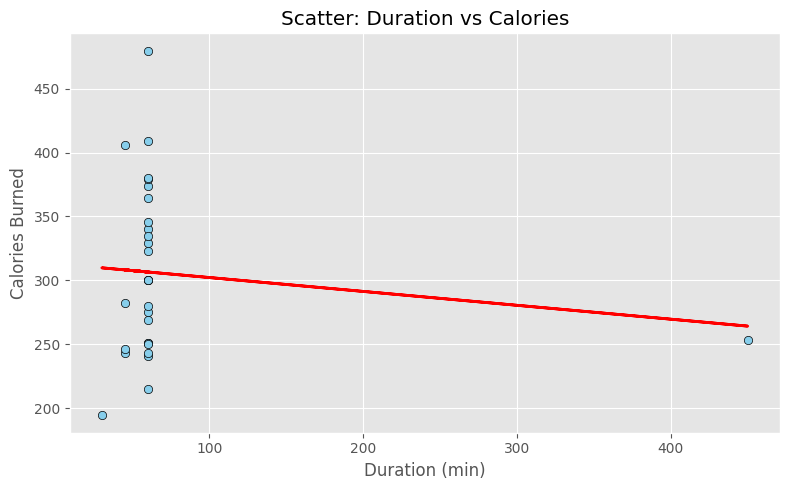

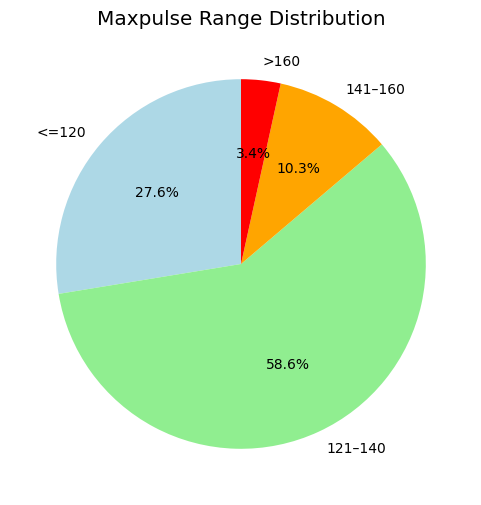

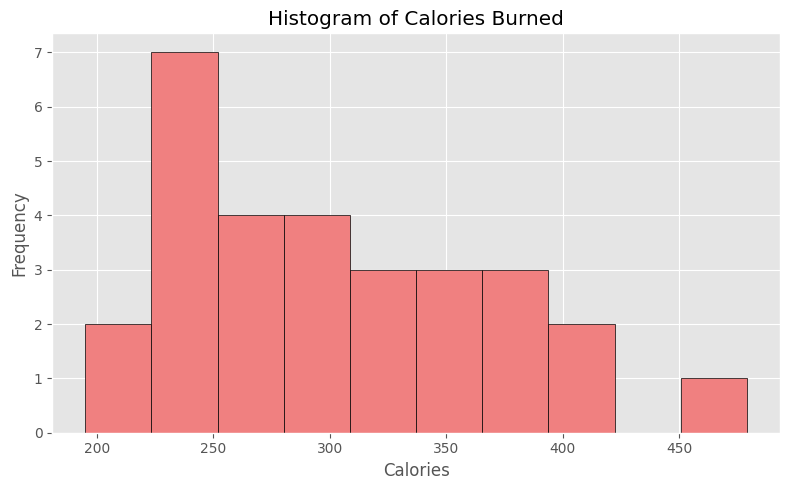

Calories distribution is right-skewed (positive skewness = 0.64)


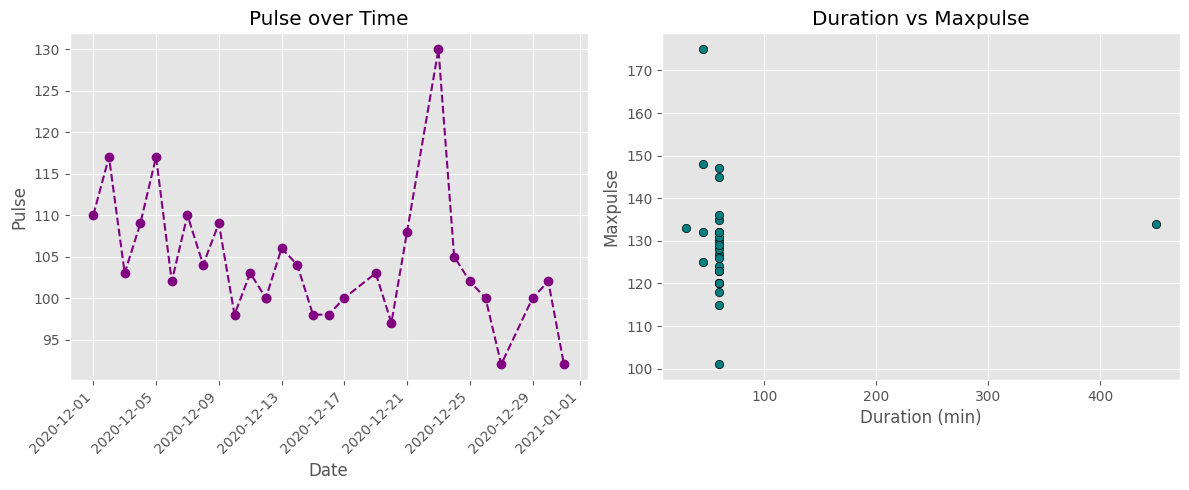


 Saved plots:
1. scatter_duration_vs_calories.png
2. pie_maxpulse_ranges.png
3. hist_calories.png
4. subplots_pulse_duration_maxpulse.png


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('data.csv')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date', 'Duration', 'Calories', 'Pulse', 'Maxpulse'])
for col in ['Duration', 'Calories', 'Pulse', 'Maxpulse']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
#1
plt.figure(figsize=(8, 5))
plt.scatter(df['Duration'], df['Calories'], color='skyblue', edgecolor='black')
corr = df['Duration'].corr(df['Calories'])
print(f"Pearson correlation (Duration vs Calories): {corr:.3f}")
m, b = np.polyfit(df['Duration'], df['Calories'], 1)
plt.plot(df['Duration'], m * df['Duration'] + b, color='red', linewidth=2)
plt.title("Duration vs Calories")
plt.xlabel("Duration (min)")
plt.ylabel("Calories Burned")
plt.grid(True)
plt.tight_layout()
plt.savefig("scatter_duration_vs_calories.png")
plt.show()
#2
bins = [0, 120, 140, 160, np.inf]
labels = ['<=120', '121–140', '141–160', '>160']
df['Maxpulse_range'] = pd.cut(df['Maxpulse'], bins=bins, labels=labels)
pulse_counts = df['Maxpulse_range'].value_counts().sort_index()
plt.figure(figsize=(6, 6))
plt.pie(pulse_counts, labels=pulse_counts.index, autopct='%1.1f%%',
        colors=['lightblue', 'lightgreen', 'orange', 'red'], startangle=90)
plt.title("Maxpulse Range Distribution")
plt.savefig("pie_maxpulse_ranges.png")
plt.show()
#3
plt.figure(figsize=(8, 5))
plt.hist(df['Calories'], bins=10, color='lightcoral', edgecolor='black')
plt.title("Histogram of Calories Burned")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.savefig("hist_calories.png")
plt.show()
skewness = df['Calories'].skew()
if skewness > 0:
    print(f"Calories distribution is right-skewed (positive skewness = {skewness:.2f})")
elif skewness < 0:
    print(f"Calories distribution is left-skewed (negative skewness = {skewness:.2f})")
else:
    print("Calories distribution is approximately symmetric.")
#4
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(df['Date'], df['Pulse'], marker='o', linestyle='--', color='purple')
plt.title("Pulse over Time")
plt.xlabel("Date")
plt.ylabel("Pulse")
plt.grid(True)
plt.xticks(rotation=45, ha='right')
plt.subplot(1, 2, 2)
plt.scatter(df['Duration'], df['Maxpulse'], color='teal', edgecolor='black')
plt.title("Duration vs Maxpulse")
plt.xlabel("Duration (min)")
plt.ylabel("Maxpulse")
plt.grid(True)
plt.tight_layout()
plt.savefig("subplots_pulse_duration_maxpulse.png")
plt.show()
print("\n Saved plots:")
print("1. scatter_duration_vs_calories.png")
print("2. pie_maxpulse_ranges.png")
print("3. hist_calories.png")
print("4. subplots_pulse_duration_maxpulse.png")


In [36]:
from google.colab import files
uploaded = files.upload()

Saving tip(in).csv to tip(in).csv


Task

 1. Basic Data Understanding

What does the dataset look like?

What are the column names, data types, and basic statistics?

Are there missing values or anomalies?

(No plot required — just inspection using Pandas.)



 2. Trend Analysis

How does a numerical variable (e.g., Sales) change over time or index?

Are there visible upward or downward trends?

Are there any noticeable spikes, dips, or seasonality?

lineplot



 3. Category Comparison

Which category (e.g., Region, Product, Department) contributes most to the total value?

Which categories have lower contributions?

How big is the gap between categories?

barplot



 4. Value Distribution

How are values in a numerical column distributed?

Are they concentrated around certain ranges or spread out evenly?

Are there extreme values?

histplot



 5. Relationship Between Variables

How does one numerical variable relate to another (e.g., Sales vs Profit)?

Is there any visible correlation?

Are there outliers?

scatterplot



 6. Outliers & Spread

How spread out are values in a numerical column?

Are there any outliers?

How does this spread differ across categories?

boxplot



 7. Proportions

How is the dataset divided among different categories?

Which category has the largest share?

Is the distribution balanced or skewed?

pieplot

 8. Multiple Visuals in One View

How do multiple insights look side by side?

Can we spot patterns when trend, distribution, and relationships are combined visually?

Which plot gives the clearest story?

subplots





 9. Final Task Submission

Your final notebook/script must include:

All questions answered with appropriate Matplotlib  plots.

Proper customization (titles, labels, legends, grids).

A short written note (markdown ) under each plot describing what the plot reveals.

All code should be your own — no Seaborn or external visualization librarie

In [38]:
import pandas as pd
df = pd.read_csv('tip(in).csv')

First 5 rows:
    total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Column names and data types:
 total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object

Basic statistics:
        total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000

Missing values:
 total_bill    0
tip           0
sex           

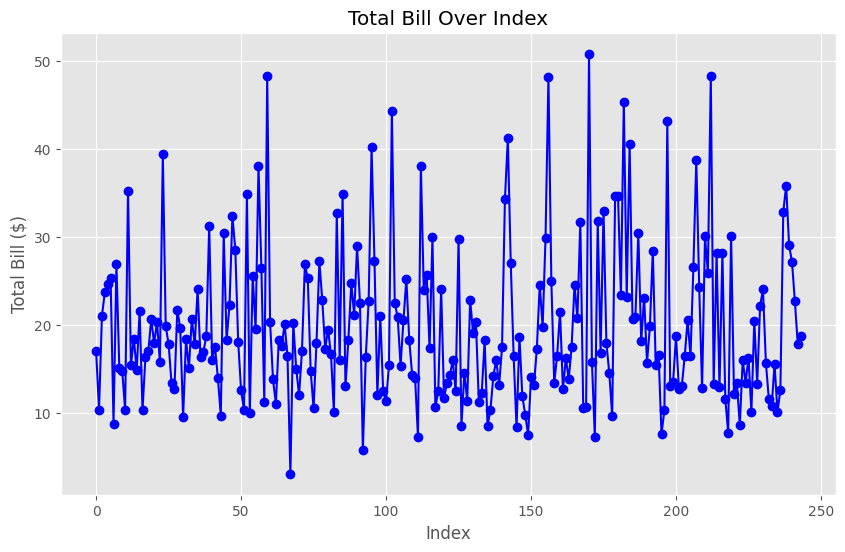

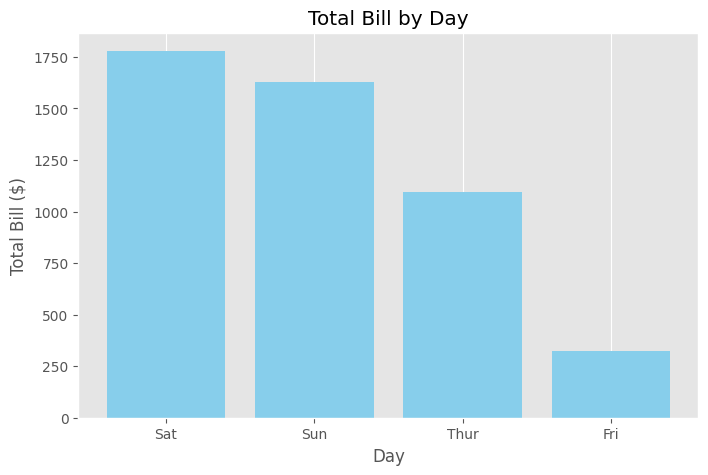

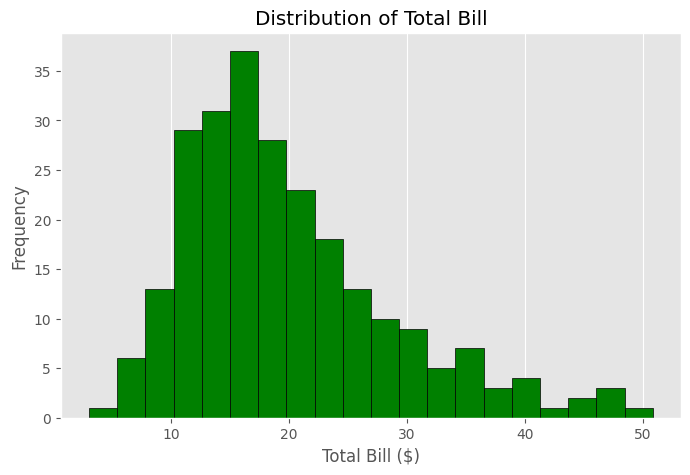

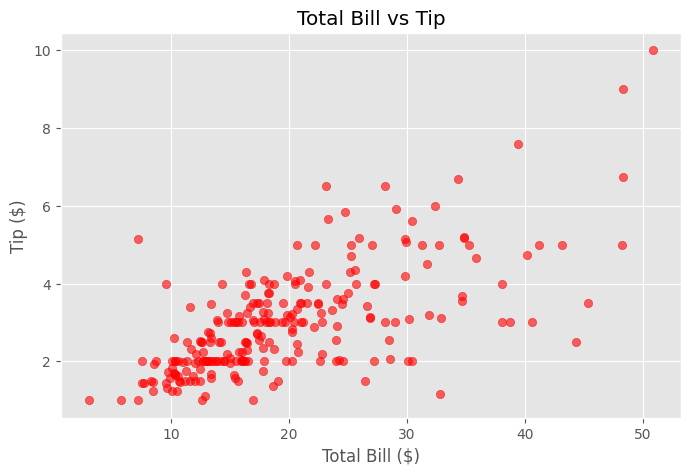

/tmp/ipython-input-3593392756.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['day']=='Thur']['total_bill'],


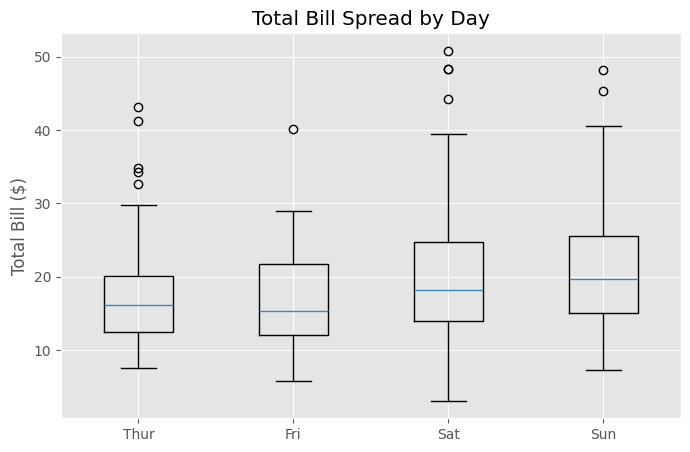

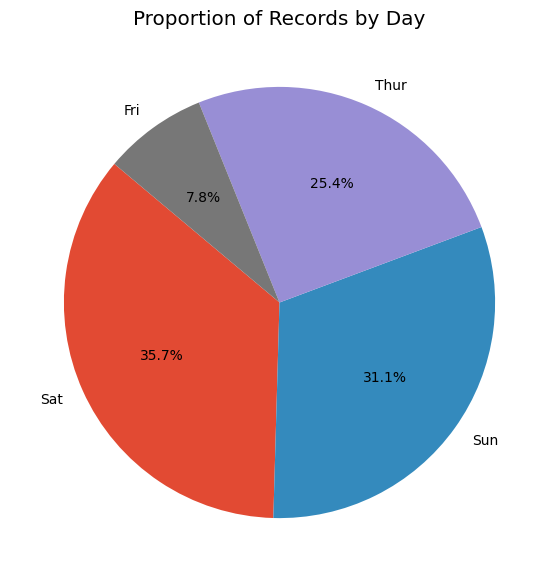

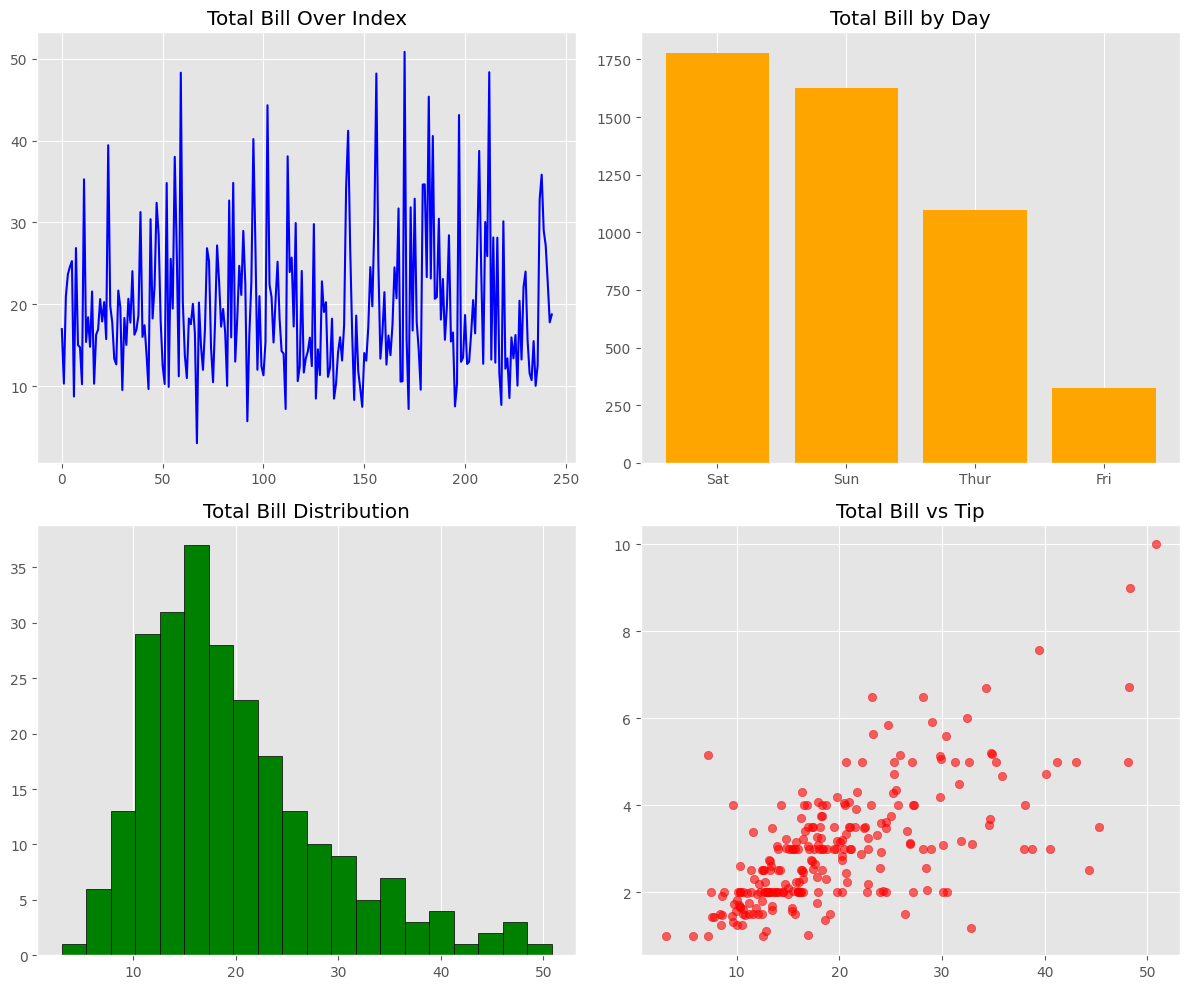

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("tip(in).csv")
print("First 5 rows:\n", df.head())
print("\nColumn names and data types:\n", df.dtypes)
print("\nBasic statistics:\n", df.describe())
print("\nMissing values:\n", df.isnull().sum())
print("\nNegative values (anomalies):\n", df[(df['total_bill'] < 0) | (df['tip'] < 0)])
#2
plt.figure(figsize=(10,6))
plt.plot(df.index, df['total_bill'], marker='o', linestyle='-', color='b')
plt.title("Total Bill Over Index")
plt.xlabel("Index")
plt.ylabel("Total Bill ($)")
plt.grid(True)
plt.show()
#3
day_total = df.groupby('day')['total_bill'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(day_total.index, day_total.values, color='skyblue')
plt.title("Total Bill by Day")
plt.xlabel("Day")
plt.ylabel("Total Bill ($)")
plt.grid(axis='y')
plt.show()
#4
plt.figure(figsize=(8,5))
plt.hist(df['total_bill'], bins=20, color='green', edgecolor='black')
plt.title("Distribution of Total Bill")
plt.xlabel("Total Bill ($)")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()
#5
plt.figure(figsize=(8,5))
plt.scatter(df['total_bill'], df['tip'], color='red', alpha=0.6)
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.grid(True)
plt.show()
#6
plt.figure(figsize=(8,5))
plt.boxplot([df[df['day']=='Thur']['total_bill'],
             df[df['day']=='Fri']['total_bill'],
             df[df['day']=='Sat']['total_bill'],
             df[df['day']=='Sun']['total_bill']],
            labels=['Thur','Fri','Sat','Sun'])
plt.title("Total Bill Spread by Day")
plt.ylabel("Total Bill ($)")
plt.grid(True)
plt.show()
#7
day_counts = df['day'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(day_counts, labels=day_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Proportion of Records by Day")
plt.show()
#8
fig, axs = plt.subplots(2, 2, figsize=(12,10))
# Line plot
axs[0,0].plot(df.index, df['total_bill'], color='blue')
axs[0,0].set_title("Total Bill Over Index")
axs[0,0].grid(True)
# Bar plot
axs[0,1].bar(day_total.index, day_total.values, color='orange')
axs[0,1].set_title("Total Bill by Day")
axs[0,1].grid(axis='y')
# Histogram
axs[1,0].hist(df['total_bill'], bins=20, color='green', edgecolor='black')
axs[1,0].set_title("Total Bill Distribution")
axs[1,0].grid(axis='y')
# Scatter plot
axs[1,1].scatter(df['total_bill'], df['tip'], color='red', alpha=0.6)
axs[1,1].set_title("Total Bill vs Tip")
axs[1,1].grid(True)
plt.tight_layout()
plt.show()